# Transient Universe

In [35]:
import numpy as np 
import matplotlib.pyplot as plt 
import sys 
sys.path.append(r"C:\Users\ricca\Documents\Unimib-Code\Astrostatistics\Notebooks")
from Utilities import plot_settings

In [36]:
data = np.load(r"C:\Users\ricca\Documents\Unimib-Code\AstroStatistics\Notebooks\Data\transient.npy")

In [37]:
time = data.T[0]
flux = data.T[1]
ferr = data.T[2]

In [39]:
b_estimate = np.mean(flux[time < 40])
A_estimate = np.max(flux)-b_estimate
t0_estimate= time[np.argmax(flux)]
a = np.where(flux-b_estimate < A_estimate/np.e , time, flux)
alpha_estimate = 1/(a[a>t0_estimate][0]-t0_estimate)

In [40]:
x0 = np.array([A_estimate, t0_estimate, alpha_estimate, b_estimate])

In [41]:
x0_dict = dict(zip(['A', 't0', 'alpha', 'b'], x0))

In [42]:
import pymc as pm

In [ ]:
with pm.Model() as model:

    # Priors:
    A = pm.Uniform('A', lower=0, upper=50)
    b = pm.Uniform('b', lower=0, upper=50)
    alpha = pm.Uniform('alpha', lower=0, upper=100)
    t0 = pm.Uniform('t0', lower=0, upper=100)  # adjust bounds as needed
    
    # Expected transient signal model:
    mu = pm.math.switch(time < t0, b, b + A * pm.math.exp(-alpha * (time - t0)))

    # Likelihood assuming Gaussian errors:
    likelihood = pm.Normal('obs', mu=mu, sigma=ferr, observed=flux)

    # Sampling:
    trace = pm.sample(draws=1000, tune=500, chains=4, target_accept=0.99, initvals=x0_dict)


ValueError: Invalid key found in step_kwargs: {'nuts'}. Keys must be step names and values valid kwargs for that stepper. Did you mean {"nuts": {"nuts": ...}}?

In [71]:
import arviz as az

In [72]:
summary = az.summary(trace,
                     stat_focus="median",
                     hdi_prob=0.9,
                     kind="stats"
                     )

print(summary)

       median    mad  eti_5%  eti_95%
A       5.045  1.905   2.079    8.367
b      10.557  0.006  10.231   10.562
alpha   0.184  0.032   0.136    0.217
t0     36.662  5.918  29.626   51.862


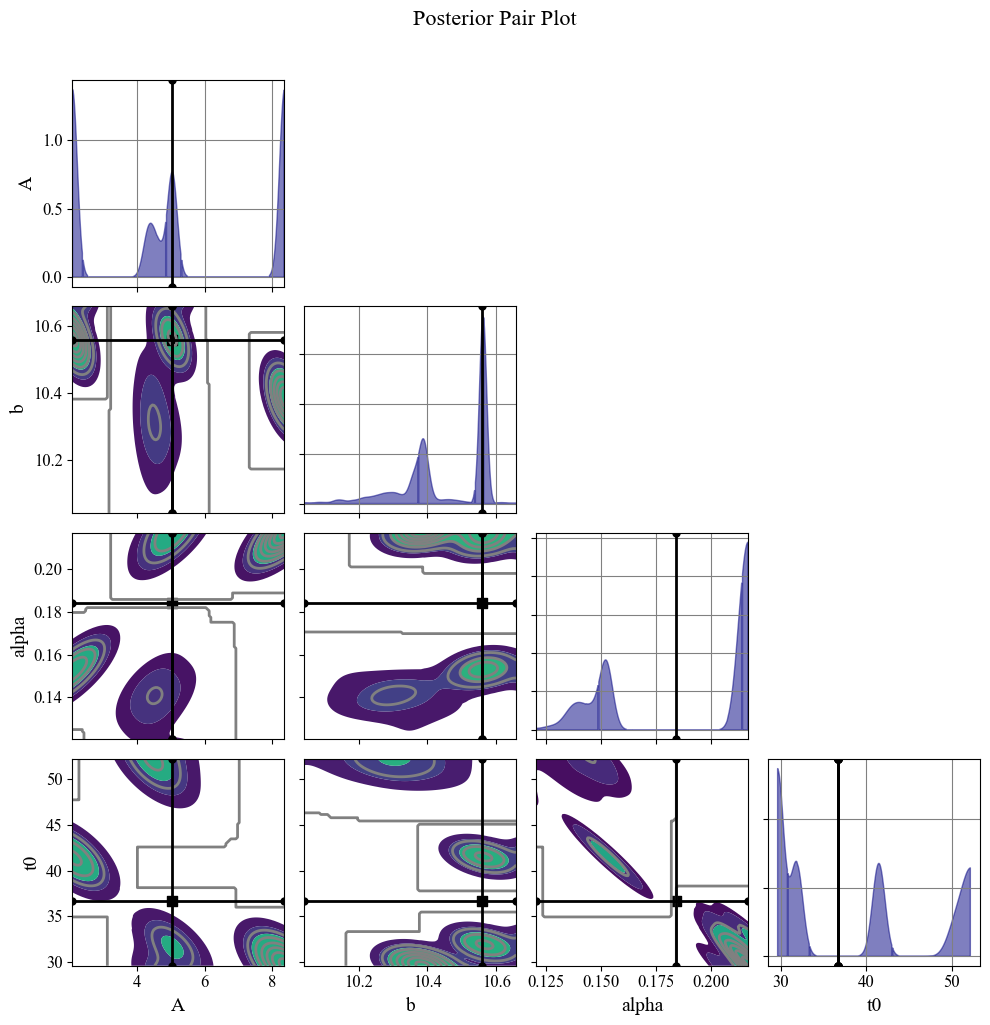

In [73]:
# Plot KDE pair plot with marginal histograms
az.plot_pair(
    trace,
    kind="kde",
    divergences=False,
    colorbar=True,
    marginals=True,
    point_estimate="median",         
    figsize=(10, 10),
    textsize=12,
    point_estimate_kwargs={'color': 'black', 'marker': 'o', 'markersize': 5},
    marginal_kwargs={'quantiles': [.25, .5, .75], 'contour': True, 
                     'fill_kwargs': {'alpha': 0.5},
                     'plot_kwargs': {'color': 'navy', 'linewidth': 2}},
    kde_kwargs={'contour': True, 'fill_kwargs': {'alpha': 0.5, 'linestyle': 'solid'}}
)

plt.suptitle("Posterior Pair Plot", fontsize=16, y=1.02)
plt.tight_layout()